# CSIS 3290 – 004 – Final Project 
- Student Name: Isaac David Rangel Blanco
- ID: 300410730

In this project, I am using a dataset of New York City Yellow taxi trips in January of 2026, to demonstrate my learning in this course and to apply the machine learning skills I have acquired. I will perform data analysis and build predictive models to estimate taxi trip fares based on features such as trip distance, passenger count, time of day, and surcharges.

- Link reference: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## Problem

For this project i want to predict the **total_amount** of NYC Yellow taxi trips using operational trip features such as distance, duration, pickup/drop-off zones, and rate type. 

## Dataset description

The original dataset contains aprox 4 millions of trips but i going to use just a sample of 200k of these records, with features like `trip_distance`, `passenger_count`, `RatecodeID`, pickup and drop-off locations (`PULocationID`, `DOLocationID`), and fare components (`fare_amount`, `Extra`, `tpep_pickup_datetime` and `tpep_dropoff_datetime` , etc.). 

The files **"data_dictionary_trip_records_yellow.pdf"** and **"taxi_zone_lookup.csv"** were important for understanding the dataset and mapping LocationID values to service zones during data transformation.

# Loading the Necessary Libraries

In [1]:
# Install pip of some models libraries
# pip install hdbscan
# pip install catboost

In [2]:
# Basic libraries Pandas, Numpy
import numpy as np
import pandas as pd

In [3]:
# Libraries for plotting and EDA
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Libraries for predictive models
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor 

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.linear_model import SGDRegressor

# Reading the dataset

The original dataset is in .parquet format, which is a columnar storage file format commonly used for big data applications. 
For this project, i convert the dataset to .csv using pandas to simplify data handling in Python and to ensure compatibility with tools that may not support Parquet files. 

link reference:
https://stackoverflow.com/questions/51215166/convert-parquet-to-csv

In [5]:
# The format of the original data set is .parquet , we can convert it to .csv

#df = pd.read_parquet("Dataset/yellow_tripdata_2026-01.parquet")

#df.info()

In [6]:
# Also i take a sample of the original data because this contains more than 3 millions of rows
# i select just 200k from the orignal dataset, more than enough data (>=10k)

#df = df.sample(200000, random_state=42)

# Saving the sample from the original dataset in csv format

#df.to_csv("Dataset/taxi_data.csv", index=False)

 The df.sample() implementation allows me to:
- Randomly selects rows from a DataFrame.
- Often is used to create a subset for testing, debugging, or sampling data.

link reference:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html

In [7]:
# Reading the new dataset that is a sample from the original dataset

df=pd.read_csv('Dataset/taxi_data.csv')

# Having a peek of the data

In [8]:
# checking the content of the data frame

df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,NaN,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,NaN,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75
5,2,2026-01-27 09:30:30,2026-01-27 09:44:06,2.0,1.21,1.0,N,141,262,1,12.80,0.00,0.5,3.36,0.00,1.0,20.16,2.5,0.0,0.00
6,2,2026-01-30 07:17:23,2026-01-30 07:30:00,NaN,4.64,NaN,NaN,56,9,0,27.88,0.00,0.5,0.00,0.00,1.0,29.38,NaN,NaN,0.00
7,2,2026-01-22 21:18:42,2026-01-22 21:32:22,1.0,2.98,1.0,N,229,238,1,15.60,1.00,0.5,2.50,0.00,1.0,23.85,2.5,0.0,0.75
8,1,2026-01-31 13:34:38,2026-01-31 13:40:13,2.0,1.10,1.0,N,263,75,1,7.20,2.50,0.5,2.25,0.00,1.0,13.45,2.5,0.0,0.00
9,2,2026-01-22 16:31:24,2026-01-22 16:34:55,1.0,3.48,5.0,N,265,265,1,40.00,0.00,0.0,0.00,0.00,1.0,41.00,0.0,0.0,0.00


In [9]:
# Checking the data types, number of columns and rows
# Also the Null values in each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               200000 non-null  int64  
 1   tpep_pickup_datetime   200000 non-null  object 
 2   tpep_dropoff_datetime  200000 non-null  object 
 3   passenger_count        141725 non-null  float64
 4   trip_distance          200000 non-null  float64
 5   RatecodeID             141725 non-null  float64
 6   store_and_fwd_flag     141725 non-null  object 
 7   PULocationID           200000 non-null  int64  
 8   DOLocationID           200000 non-null  int64  
 9   payment_type           200000 non-null  int64  
 10  fare_amount            200000 non-null  float64
 11  extra                  200000 non-null  float64
 12  mta_tax                200000 non-null  float64
 13  tip_amount             200000 non-null  float64
 14  tolls_amount           200000 non-nu

# Cleaning the data
- The dataframe can be cleaned by changing label names, dropping and filling some data.
  
- Additionally, some features, such as **tpep_pickup_datetime** and **tpep_dropoff_datetime**, can be transformed into a more understandable format. For example, these two columns can be combined into a single feature that represents the total duration of the trip. Since all the data corresponds to January 2026, it is also possible to extract only the day and hour from the datetime values.
  
- Some columns in the dataset contain ID values; however, these do not correspond to unique user identifiers but instead represent categorical information, such as service providers (VendorID) and fare types (RatecodeID). Therefore, these variables are treated as categorical features and appropriately encoded before being used in the machine learning models:

- **VendorID:** A code indicating the TPEP provider of the record.
1 = Creative Mobile Technologies, LLC
2 = Curb Mobility, LLC
6 = Myle Technologies Inc
7 = Helix

- **RatecodeID:** The final rate code in effect at the end of the trip. 1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown

- **payment_type:** A numeric code signifying how the passenger paid for the trip.
0 = Flex Fare trip
1 = Credit card
2 = Cash
3 = No charge
4 = Dispute
5 = Unknown
6 = Voided trip

- **store_and_fwd_flag:** This flag indicates whether the trip record was held in vehicle memory before
sending to the vendor, aka “store and forward,” because the vehicle did not
have a connection to the server.
Y = store and forward trip
N = not a store and forward trip
 
- **PULocationID:** Pick Up - TLC Taxi Zone in which the taximeter was engaged.
 
- **DOLocationID:** Drop Off - TLC Taxi Zone in which the taximeter was disengaged.

Due to the high cardinality of the pickup and dropoff location identifiers, that are 265 different locations, these variables can be removed to simplify the model and avoid overfitting. Or as better option to avoid losing data, we can change this IDs to his respective service_zone(for this is necessary to check an extra dataset that contains this information)

Note: Previus data was obtained from the Data Dictionary provided from the link reference

In [10]:
# Creating a copy from the dataset 
df1 = df.copy()

## Changing Labels Names

In [11]:
# first removing any white space, and formatting to capital letter
# i prefer to keep the underscores for this dataset

df1.columns = df1.columns.str.title().str.replace(" ","")
df1.head()

,Vendorid,Tpep_Pickup_Datetime,Tpep_Dropoff_Datetime,Passenger_Count,Trip_Distance,Ratecodeid,Store_And_Fwd_Flag,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,NaN,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,NaN,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75


## Formatting DateTime columns

In [12]:
# modifiying datetime columns  	
# getting just the time from the tpep_pickup_datetime and tpep_dropoff_datetime columns

df1['PU_Time'] = df1['Tpep_Pickup_Datetime'].apply(lambda x: x.split()[1])  
df1['DO_Time'] = df1['Tpep_Dropoff_Datetime'].apply(lambda x: x.split()[1]) 


In [13]:
# changing the format from 21:18:42 to just minutes

df1['PU_Time'] = df1['PU_Time'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]) + int(x.split(':')[2])/60)
df1['DO_Time'] = df1['DO_Time'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]) + int(x.split(':')[2])/60)

# Creating duration column to simplify this data

df1['Trip_Duration'] = df1.apply(lambda row: row['DO_Time'] - row['PU_Time']
                                   if row['DO_Time'] >= row['PU_Time']
                                   else row['DO_Time'] - row['PU_Time'] + 24*60,axis=1)

# Dropping columns that were formated 

df1 = df1.drop(columns=['Tpep_Pickup_Datetime','Tpep_Dropoff_Datetime','PU_Time','DO_Time'])

In [14]:
df1.head()

,Vendorid,Passenger_Count,Trip_Distance,Ratecodeid,Store_And_Fwd_Flag,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
0,1,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75,10.866667
1,2,NaN,13.95,NaN,NaN,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00,32.800000
2,2,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75,30.383333
3,2,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75,10.200000
4,2,NaN,7.42,NaN,NaN,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75,14.300000


## Columns with IDs 

In [15]:
# Changing the columns IDs with the respectivy categorical data

df1['Vendor']= df1['Vendorid'].replace({1: "Creative",2: "Curb",6: "Myle",7: "Helix"})

df1['Rate_Type'] = df1['Ratecodeid'].replace({1: "Standard rate",2: "JFK",3: "Newark",4: "Nassau",5: "Negotiated",6: "Group",99: pd.NA})

df1['Payment_Type'] = df1['Payment_Type'].replace({0: "Flex Fare",1: "Credit card",2: "Cash",3: "No charge",4: "Dispute",5: pd.NA,6: "Voided trip"})

df1['Stored_Flag'] = df1['Store_And_Fwd_Flag']


# Reducing the name size of the column 'Store_And_Fwd_Flag' by saving it in a new column

df1['Stored_Flag'] = df1['Store_And_Fwd_Flag']

# Then drop the original column
df1 = df1.drop(columns=['Store_And_Fwd_Flag','Vendorid','Ratecodeid'])

df1.head()

,Passenger_Count,Trip_Distance,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag
0,1.0,3.90,68,238,Credit card,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75,10.866667,Creative,Standard rate,N
1,NaN,13.95,69,61,Flex Fare,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00,32.800000,Curb,NaN,NaN
2,1.0,13.79,13,138,Credit card,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75,30.383333,Curb,Standard rate,N
3,1.0,1.76,164,79,Cash,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75,10.200000,Curb,Standard rate,N
4,NaN,7.42,74,232,Flex Fare,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75,14.300000,Curb,NaN,NaN


## PU(Pick Up) and DO(Drop Off) location columns

In [16]:
# Using an additional "Taxi Zones LookUp" Dataset and implementing some feature engineer techniques to modify these columns

# This data set contains the service zone for all the 265 locationIDs, so we first check the content 
taxi_zones = pd.read_csv('Dataset/taxi_zone_lookup.csv')
taxi_zones.head(10)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
5,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
6,7,Queens,Astoria,Boro Zone
7,8,Queens,Astoria Park,Boro Zone
8,9,Queens,Auburndale,Boro Zone
9,10,Queens,Baisley Park,Boro Zone


In [17]:
# Info of this additional data set
taxi_zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       264 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [18]:
# Cheking value count for the columns
# 4 categories for service zone, we can use this instead of the 265 locationIDs
taxi_zones.service_zone.value_counts()

service_zone
Boro Zone      205
Yellow Zone     55
Airports         2
EWR              1
Name: count, dtype: int64

In [19]:
# Value counts for the other 2 columns,
# These have to many categories, so is better using the Service Zones categories
taxi_zones.Zone.value_counts()

Zone
Governor's Island/Ellis Island/Liberty Island    3
Corona                                           2
Newark Airport                                   1
Ocean Hill                                       1
Parkchester                                      1
                                                ..
Fordham South                                    1
Forest Hills                                     1
Forest Park/Highland Park                        1
Fort Greene                                      1
Outside of NYC                                   1
Name: count, Length: 261, dtype: int64

In [20]:
taxi_zones.Borough.value_counts()

Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Unknown           1
Name: count, dtype: int64

 Mapping with dict + .map() allows me to:
 - create a dictionary from the additonal Dataframe by mapping each LocationID to a service zone.
 - Then use .map() to assign pickup and drop-off zones in original DataFrame.

Link reference:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html

In [21]:
# Creating a dictionary from the taxi_zones dataset to obtain the respective service_zone for each locationID for PU or DO

location_to_service = dict(zip(taxi_zones["LocationID"], taxi_zones["service_zone"]))

In [22]:
# Mapping PickUp and DropOff locationID, also creating new column with the service zone
df1["PU_zone"] = df1["Pulocationid"].map(location_to_service)

df1["DO_zone"] = df1["Dolocationid"].map(location_to_service)

# Dropping "PULocationID" and "DOLocationID", since we have new columns that refers to this features
df1 = df1.drop(columns=["Pulocationid", "Dolocationid"])

# Now instead of having IDs that refer to categorical data, we have the respective categorical data (4 categories)

df1.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
0,1.0,3.90,Credit card,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75,10.866667,Creative,Standard rate,N,Yellow Zone,Yellow Zone
1,NaN,13.95,Flex Fare,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00,32.800000,Curb,NaN,NaN,Boro Zone,Boro Zone
2,1.0,13.79,Credit card,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75,30.383333,Curb,Standard rate,N,Yellow Zone,Airports
3,1.0,1.76,Cash,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75,10.200000,Curb,Standard rate,N,Yellow Zone,Yellow Zone
4,NaN,7.42,Flex Fare,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75,14.300000,Curb,NaN,NaN,Boro Zone,Yellow Zone


In [23]:
# checking the value count for the new columns
df1.PU_zone.value_counts()

PU_zone
Yellow Zone    163347
Boro Zone       23473
Airports        12833
EWR                31
Name: count, dtype: int64

In [24]:
# For PU and DU now is jsut 4 categories
df1.DO_zone.value_counts()

DO_zone
Yellow Zone    160450
Boro Zone       35137
Airports         2889
EWR               326
Name: count, dtype: int64

In [25]:
df1.Stored_Flag.value_counts()

Stored_Flag
N    141596
Y       129
Name: count, dtype: int64

In [26]:
# checking again the info of the data set after the changes
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        141725 non-null  float64
 1   Trip_Distance          200000 non-null  float64
 2   Payment_Type           200000 non-null  object 
 3   Fare_Amount            200000 non-null  float64
 4   Extra                  200000 non-null  float64
 5   Mta_Tax                200000 non-null  float64
 6   Tip_Amount             200000 non-null  float64
 7   Tolls_Amount           200000 non-null  float64
 8   Improvement_Surcharge  200000 non-null  float64
 9   Total_Amount           200000 non-null  float64
 10  Congestion_Surcharge   141725 non-null  float64
 11  Airport_Fee            141725 non-null  float64
 12  Cbd_Congestion_Fee     200000 non-null  float64
 13  Trip_Duration          200000 non-null  float64
 14  Vendor                 200000 non-nu

In [27]:
df1.describe()

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,141725.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,141725.000000,141725.000000,200000.000000,200000.000000
mean,1.256151,8.864062,20.788241,1.025476,0.483035,2.601568,0.498819,0.947259,29.155211,2.151332,0.148201,0.518887,17.192478
std,0.672240,898.268354,19.054989,1.709232,0.115703,3.857137,2.118720,0.267624,22.689811,0.946893,0.540254,0.357164,24.666202
min,0.000000,0.000000,-669.400000,-7.500000,-0.500000,-50.000000,-35.310000,-1.000000,-670.400000,-2.500000,-1.750000,-0.750000,0.000000
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,16.960000,2.500000,0.000000,0.000000,8.066667
50%,1.000000,1.810000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,23.040000,2.500000,0.000000,0.750000,13.350000
75%,1.000000,3.720000,26.100000,2.500000,0.500000,3.710000,0.000000,1.000000,33.720000,2.500000,0.000000,0.750000,21.150000
max,6.000000,221544.910000,893.400000,13.250000,0.500000,300.000000,57.000000,1.000000,904.110000,2.500000,26.750000,0.750000,1439.416667


## Columns with Null Values

In [28]:
# Passenger_Count column 
# replacing the Null values with the mode

print(df1.Passenger_Count.mode())
df1['Passenger_Count'] = df1['Passenger_Count'].fillna(df1['Passenger_Count'].mode()[0])

0    1.0
Name: Passenger_Count, dtype: float64


In [29]:
# The RatecodeID is the final rate code in effect at the end of the trip. 
print(df1.Rate_Type.mode())

# replacing the Null values with the mode
df1['Rate_Type'] = df1['Rate_Type'].fillna(df1['Rate_Type'].mode()[0])

0    Standard rate
Name: Rate_Type, dtype: object


In [30]:
# Congestion_Surcharge and Airport_Fee columns
# If the value is NaN, this means the fee was not applied, so it can be set to 0.

df1['Congestion_Surcharge'] = df1['Congestion_Surcharge'].fillna(0)
df1['Airport_Fee'] = df1['Airport_Fee'].fillna(0)

In [31]:
# Stored_Flag column , 
# replacing the Null values with the most frequent category or mode

print(df1['Stored_Flag'].mode())
df1['Stored_Flag'] = df1['Stored_Flag'].fillna(df1['Stored_Flag'].mode()[0])

0    N
Name: Stored_Flag, dtype: object


In [32]:
# Finally, we can drop the null values in the PU_zone and DO_zone columns
# Because these represent a very small portion of the dataset.

print(df1.DO_zone.isnull().sum())
df1.PU_zone.isnull().sum()

df1 = df1.dropna(subset=['PU_zone', 'DO_zone'])

1198


In [33]:
# Checking again the info to see the null values
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198645 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        198645 non-null  float64
 1   Trip_Distance          198645 non-null  float64
 2   Payment_Type           198645 non-null  object 
 3   Fare_Amount            198645 non-null  float64
 4   Extra                  198645 non-null  float64
 5   Mta_Tax                198645 non-null  float64
 6   Tip_Amount             198645 non-null  float64
 7   Tolls_Amount           198645 non-null  float64
 8   Improvement_Surcharge  198645 non-null  float64
 9   Total_Amount           198645 non-null  float64
 10  Congestion_Surcharge   198645 non-null  float64
 11  Airport_Fee            198645 non-null  float64
 12  Cbd_Congestion_Fee     198645 non-null  float64
 13  Trip_Duration          198645 non-null  float64
 14  Vendor                 198645 non-null  o

In [34]:
# The summary statistics of the data after the formatting, droppin some null values and filling data

df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000,198645.000000
mean,1.180634,8.838019,20.488722,1.021279,0.484029,2.569357,0.471649,0.947285,28.802536,1.529374,0.101815,0.520218,17.110982
std,0.575900,901.325995,17.668608,1.705157,0.113602,3.675356,1.989201,0.267237,21.188951,1.260497,0.453979,0.356635,24.533001
min,0.000000,0.000000,-600.000000,-7.500000,-0.500000,-50.000000,-26.240000,-1.000000,-601.000000,-2.500000,-1.750000,-0.750000,0.000000
1%,1.000000,0.000000,-3.000000,0.000000,-0.500000,0.000000,0.000000,-1.000000,-8.400000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,16.950000,0.000000,0.000000,0.000000,8.050000
50%,1.000000,1.800000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,22.960000,2.500000,0.000000,0.750000,13.316667
75%,1.000000,3.690000,25.860000,2.500000,0.500000,3.700000,0.000000,1.000000,33.580000,2.500000,0.000000,0.750000,21.050000
99%,4.000000,19.200000,76.485600,6.000000,0.500000,16.800000,7.460000,1.000000,102.601200,2.500000,1.750000,0.750000,71.002000
max,6.000000,221544.910000,680.190000,13.250000,0.500000,99.990000,57.000000,1.000000,684.190000,2.500000,26.750000,0.750000,1439.416667


# Analyze and display some interesting data of some features
- By using the summary statistics and the data dictionary that describes the original data set

In [35]:
# Very long trips (trip_distance > 0.99 quantile) , this feature is mesured in miles
# Creating a new data frame with all the records that are greater than the 99% of the data

long_dist = df1[df1['Trip_Distance'] >= df1['Trip_Distance'].quantile(0.99)]
long_dist.head(10)

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
60,1.0,20.06,Credit card,70.00,0.0,0.5,16.44,7.46,1.0,98.65,2.5,0.00,0.75,28.633333,Curb,JFK,N,Yellow Zone,Airports
331,1.0,25.72,Cash,99.60,1.0,0.5,0.00,0.00,1.0,103.85,0.0,1.75,0.00,43.550000,Curb,Standard rate,N,Airports,Boro Zone
342,2.0,24.02,Credit card,107.70,1.0,0.0,10.00,23.06,1.0,143.51,0.0,0.00,0.75,30.983333,Curb,Newark,N,Yellow Zone,EWR
346,1.0,21.40,Cash,70.00,5.0,0.5,0.00,7.46,1.0,83.96,2.5,1.75,0.75,38.666667,Creative,JFK,N,Airports,Yellow Zone
453,1.0,20.30,Credit card,70.00,5.0,0.5,15.30,0.00,1.0,91.80,2.5,1.75,0.75,65.483333,Creative,JFK,N,Airports,Yellow Zone
807,1.0,20.62,Flex Fare,67.75,0.0,0.5,15.99,7.46,1.0,95.95,0.0,0.00,0.75,47.550000,Curb,Standard rate,N,Yellow Zone,Airports
855,1.0,19.83,Credit card,70.00,0.0,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00,39.900000,Curb,JFK,N,Airports,Yellow Zone
1015,1.0,21.11,Credit card,81.40,2.5,0.5,21.79,0.00,1.0,108.94,0.0,1.75,0.00,41.083333,Curb,Standard rate,N,Airports,Boro Zone
1191,4.0,20.30,Credit card,70.00,0.0,0.5,10.00,6.94,1.0,92.69,2.5,1.75,0.00,38.133333,Curb,JFK,N,Airports,Yellow Zone
1223,1.0,19.41,Dispute,-73.00,0.0,-0.5,0.00,0.00,-1.0,-76.25,0.0,-1.75,0.00,38.966667,Curb,Standard rate,N,Airports,Boro Zone


In [36]:
# Pick up zone
long_dist.PU_zone.mode()

0    Airports
Name: PU_zone, dtype: object

In [37]:
# Drop OFF zone
long_dist.DO_zone.mode()

# The mode locoation for the long distances trips is from Airpots for most of the PU  and Boro zone for DO

0    Boro Zone
Name: DO_zone, dtype: object

In [38]:
# Its possible to analize now just this data because this have some outliers and i want to check the range to drop some of this records

long_dist.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1.326990,571.861537,71.619419,0.949549,0.448423,9.406124,5.439194,0.809915,91.234382,1.075363,1.082624,0.222334,54.712561
std,0.669802,8973.744868,34.514982,1.877442,0.181410,9.013061,5.749100,0.447529,41.557127,1.294916,1.011115,0.356312,39.836307
min,0.000000,19.200000,-200.000000,-6.000000,-0.500000,0.000000,-26.240000,-1.000000,-217.540000,-2.500000,-1.750000,-0.750000,0.000000
1%,1.000000,19.200000,-84.232000,0.000000,-0.500000,0.000000,-7.460000,-1.000000,-91.265600,-2.500000,-1.750000,0.000000,11.264000
25%,1.000000,19.830000,70.000000,0.000000,0.500000,0.000000,0.000000,1.000000,82.980000,0.000000,0.000000,0.000000,38.966667
50%,1.000000,20.660000,70.000000,0.000000,0.500000,10.000000,7.460000,1.000000,95.880000,0.000000,1.750000,0.000000,47.716667
75%,1.000000,23.120000,80.000000,1.000000,0.500000,16.440000,7.460000,1.000000,103.570000,2.500000,1.750000,0.750000,61.533333
99%,4.000000,44.108000,153.240000,6.750000,0.500000,28.154400,26.406000,1.000000,184.174400,2.500000,1.750000,0.750000,136.906667
max,6.000000,221544.910000,522.400000,10.000000,0.500000,90.000000,50.680000,1.000000,523.900000,2.500000,20.000000,0.750000,1403.283333


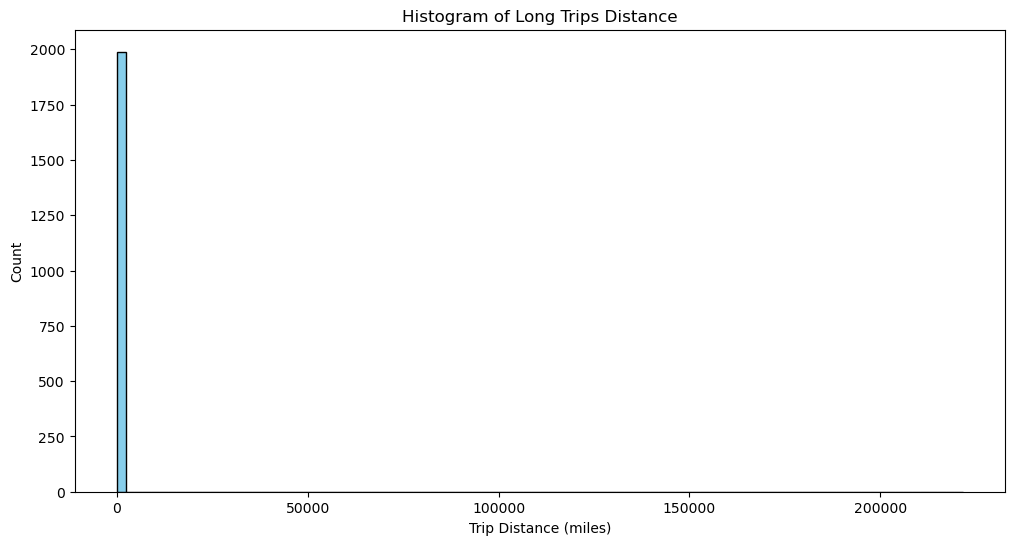

In [39]:
# Plotting the dataframe of long distance trips, we can notice that the data have outliers

plt.figure(figsize=(12,6))
plt.hist(long_dist['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Long Trips Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

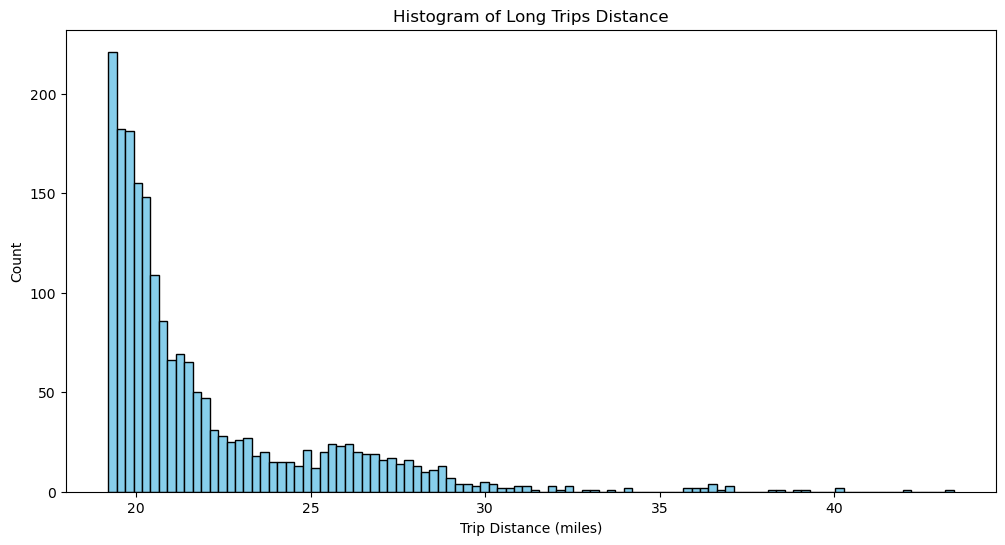

In [40]:
# Filtering the data and now its possible to check the outliers or the range in what the data looks normal distributed

ld_filtered = long_dist[long_dist['Trip_Distance'] < 44]
plt.figure(figsize=(12,6))
plt.hist(ld_filtered['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Long Trips Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

In [41]:
# For the outliers i decide to drop all the records that have more than 35 miles in the trip distance
# because they represent extreme outliers, as observed in the distribution plot and supported by percentile analysis

df1 = df1.drop(index=df1[df1['Trip_Distance'] >= 35].index)


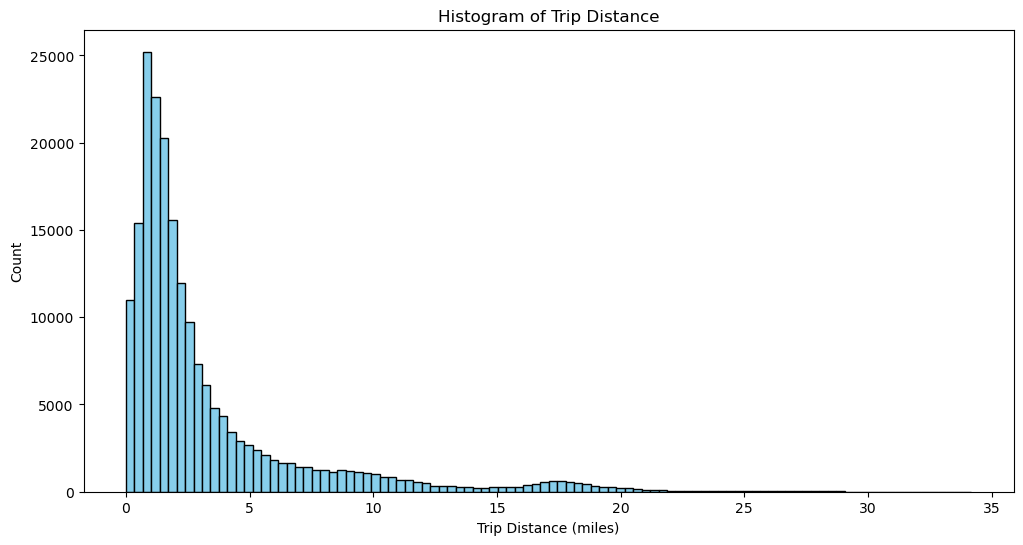

In [42]:
# Plotting again the trip distance values of the original dataset
plt.figure(figsize=(12,6))
plt.hist(df1['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

In [43]:
# Checking the info after removing outliers, aprox 40 records were removed 
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198602 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        198602 non-null  float64
 1   Trip_Distance          198602 non-null  float64
 2   Payment_Type           198602 non-null  object 
 3   Fare_Amount            198602 non-null  float64
 4   Extra                  198602 non-null  float64
 5   Mta_Tax                198602 non-null  float64
 6   Tip_Amount             198602 non-null  float64
 7   Tolls_Amount           198602 non-null  float64
 8   Improvement_Surcharge  198602 non-null  float64
 9   Total_Amount           198602 non-null  float64
 10  Congestion_Surcharge   198602 non-null  float64
 11  Airport_Fee            198602 non-null  float64
 12  Cbd_Congestion_Fee     198602 non-null  float64
 13  Trip_Duration          198602 non-null  float64
 14  Vendor                 198602 non-null  o

In [44]:
# tip_amount > 50

big_tips = df1[df1['Tip_Amount'] > 50].sample(3, random_state=42)
big_tips

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
128322,3.0,2.76,Credit card,230.00,0.0,0.0,69.30,0.0,1.0,300.30,0.0,0.0,0.00,22.066667,Curb,Negotiated,N,Boro Zone,Boro Zone
80460,3.0,6.69,Credit card,72.00,0.0,0.0,70.81,0.0,1.0,144.56,0.0,0.0,0.75,63.000000,Curb,Newark,N,Yellow Zone,Boro Zone
8289,1.0,0.00,Credit card,320.45,0.0,0.0,80.36,0.0,1.0,401.81,0.0,0.0,0.00,0.083333,Curb,Negotiated,N,Boro Zone,Boro Zone


In [45]:
# negative fares o negative total amount

negative_fares = df1[df1['Total_Amount'] < 0]
negative_fares.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
17,1.0,6.79,Dispute,-48.9,-7.5,0.0,0.0,0.0,-1.0,-59.15,0.0,-1.75,0.00,15.616667,Curb,Newark,N,Airports,Boro Zone
51,1.0,0.00,No charge,-3.0,0.0,-0.5,0.0,0.0,-1.0,-7.75,-2.5,0.00,-0.75,0.083333,Curb,Standard rate,N,Yellow Zone,Yellow Zone
228,2.0,9.66,Dispute,-80.0,0.0,-0.5,0.0,0.0,-1.0,-84.75,-2.5,0.00,-0.75,92.900000,Curb,Standard rate,N,Yellow Zone,Boro Zone
437,1.0,8.22,No charge,-32.4,-2.5,-0.5,0.0,0.0,-1.0,-38.15,0.0,-1.75,0.00,12.650000,Curb,Standard rate,N,Airports,Boro Zone
550,1.0,7.65,Dispute,-31.7,-1.0,-0.5,0.0,0.0,-1.0,-35.95,0.0,-1.75,0.00,19.250000,Curb,Standard rate,N,Airports,Boro Zone


In [46]:
# Passenger_Count > 4 , normal yellow taxi should have no more than 4 passangers usually  
# but in this case is possible to have 4 or 6 as max amount of passengers
many_passengers = df1[df1['Passenger_Count'] > 4]
many_passengers.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
16,6.0,0.69,Credit card,5.1,0.0,0.5,1.97,0.0,1.0,11.82,2.5,0.00,0.75,1.650000,Curb,Standard rate,N,Yellow Zone,Yellow Zone
252,5.0,1.67,Credit card,12.1,0.0,0.5,2.53,0.0,1.0,19.38,2.5,0.00,0.75,10.383333,Curb,Standard rate,N,Yellow Zone,Yellow Zone
528,6.0,11.12,Credit card,49.2,2.5,0.5,10.99,0.0,1.0,65.94,0.0,1.75,0.00,37.200000,Curb,Standard rate,N,Airports,Boro Zone
629,6.0,5.33,Credit card,35.9,0.0,0.5,10.16,0.0,1.0,50.81,2.5,0.00,0.75,37.933333,Curb,Standard rate,N,Yellow Zone,Yellow Zone
858,5.0,1.18,Credit card,10.0,1.0,0.5,3.15,0.0,1.0,18.90,2.5,0.00,0.75,9.050000,Curb,Standard rate,N,Yellow Zone,Yellow Zone


In [47]:
# I decide to create a new column with the base fare amount, using the tip amount feature because this is optional and depends on the passenger
# and we can use this new Base_Fare to experiment

df1['Base_Fare'] = df1['Total_Amount'] - df1['Tip_Amount']

In [48]:
# Because values like Fare_amount, Extra, Base_Fare or Total_Amount shoul not be negative, i will drop all the records with negatives fares

# First i save the index of these records
neg_indices = df1[(df1['Fare_Amount'] < 0) | (df1['Extra'] < 0) | (df1['Base_Fare'] < 0) | (df1['Total_Amount'] < 0)].index

# then i drop those records
df1 = df1.drop(index=neg_indices)

In [49]:
# summary statistics shows that the are no more negative values
df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000,196433.000000
mean,1.178880,3.298232,20.948011,1.044641,0.494634,2.596732,0.481867,0.968730,29.417075,1.567710,0.107246,0.531166,17.127918,26.820343
std,0.573773,4.030618,16.830409,1.692259,0.051518,3.675419,1.968565,0.173355,20.088851,1.208953,0.446543,0.340937,24.607452,18.304422
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.000000,0.000000,0.000000,0.000000,9.450000,0.000000,0.000000,0.000000,0.000000,8.750000
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,17.200000,0.000000,0.000000,0.000000,8.083333,15.160000
50%,1.000000,1.810000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,23.100000,2.500000,0.000000,0.750000,13.333333,20.930000
75%,1.000000,3.680000,26.100000,2.500000,0.500000,3.720000,0.000000,1.000000,33.690000,2.500000,0.000000,0.750000,21.066667,31.480000
99%,4.000000,19.100000,76.500000,6.000000,0.500000,16.800000,7.460000,1.000000,102.660000,2.500000,1.750000,0.750000,70.933333,88.960000
max,6.000000,34.180000,680.190000,13.250000,0.500000,99.990000,57.000000,1.000000,684.190000,2.500000,26.750000,0.750000,1439.416667,684.190000


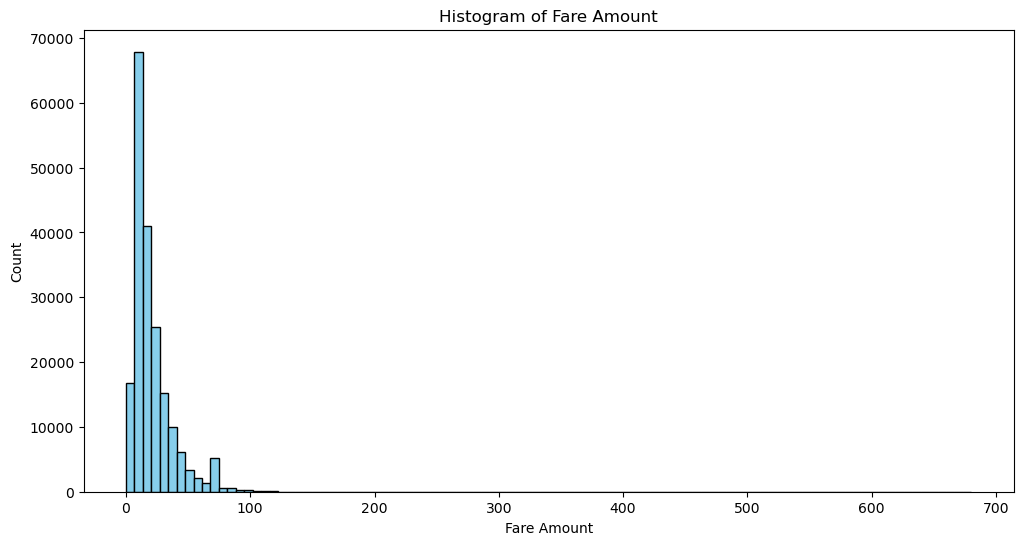

In [50]:
# Plot of Fare Amount to check outliers
plt.figure(figsize=(12,6))
plt.hist(df1['Fare_Amount'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Count')
plt.show()

In [51]:
# index of records where Fare_Amount is above the 99% percentile
outlier_indices = df1[df1['Fare_Amount'] > df1['Fare_Amount'].quantile(0.99)].index

# then drop those records
df1 = df1.drop(index=outlier_indices)

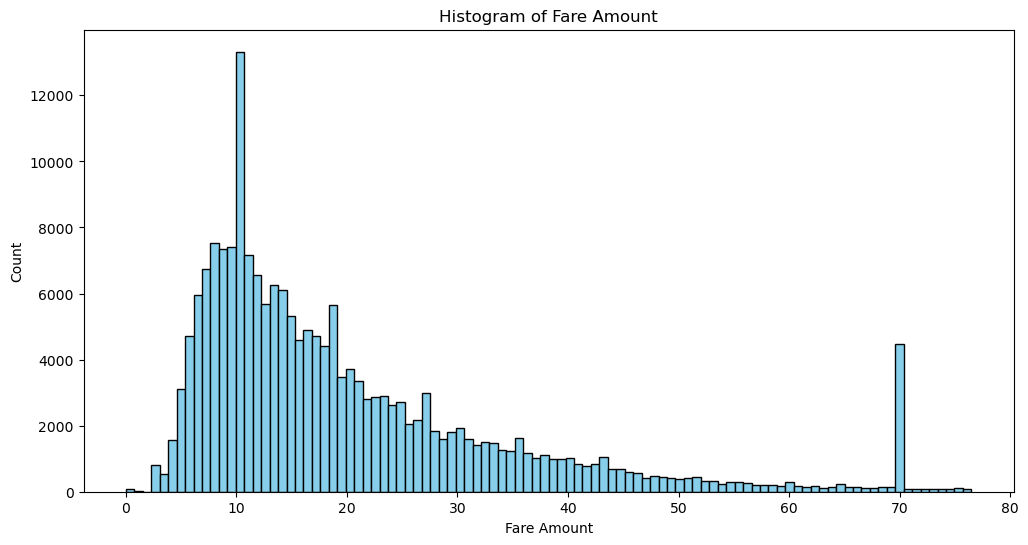

In [52]:
# Plott of Fare Amount to check the distribution after removing outliers
plt.figure(figsize=(12,6))
plt.hist(df1['Fare_Amount'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Count')
plt.show()

In [53]:
# Checking the info after removing outliers, aprox 4k records were removed 
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194495 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        194495 non-null  float64
 1   Trip_Distance          194495 non-null  float64
 2   Payment_Type           194495 non-null  object 
 3   Fare_Amount            194495 non-null  float64
 4   Extra                  194495 non-null  float64
 5   Mta_Tax                194495 non-null  float64
 6   Tip_Amount             194495 non-null  float64
 7   Tolls_Amount           194495 non-null  float64
 8   Improvement_Surcharge  194495 non-null  float64
 9   Total_Amount           194495 non-null  float64
 10  Congestion_Surcharge   194495 non-null  float64
 11  Airport_Fee            194495 non-null  float64
 12  Cbd_Congestion_Fee     194495 non-null  float64
 13  Trip_Duration          194495 non-null  float64
 14  Vendor                 194495 non-null  o

In [54]:
df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000
mean,1.176370,3.204659,20.195748,1.049371,0.496905,2.523858,0.440286,0.968475,28.559454,1.578807,0.102586,0.532849,16.915776,26.035595
std,0.569404,3.830036,14.684543,1.694939,0.039218,3.453614,1.790771,0.174036,17.826934,1.205982,0.432596,0.340161,24.189450,16.196950
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.500000,0.000000,0.000000,0.000000,9.400000,0.000000,0.000000,0.000000,0.000000,8.709400
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,17.150000,0.000000,0.000000,0.000000,8.066667,15.150000
50%,1.000000,1.800000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,23.000000,2.500000,0.000000,0.750000,13.266667,20.750000
75%,1.000000,3.600000,25.400000,2.500000,0.500000,3.700000,0.000000,1.000000,33.195000,2.500000,0.000000,0.750000,20.866667,30.940000
99%,4.000000,18.600000,70.000000,6.000000,0.500000,16.440000,7.460000,1.000000,98.880000,2.500000,1.750000,0.750000,69.600000,83.960000
max,6.000000,34.000000,76.500000,13.250000,0.500000,99.990000,57.000000,1.000000,177.920000,2.500000,26.750000,0.750000,1439.416667,135.760000


# Saving the Dataset cleaned and checking again the content

In [55]:
# Saving the dataset cleaned 

df1.to_csv("Dataset/taxi_data_cleaned.csv", index=False)

In [56]:
# Reading the new dataset cleaned

df_cleaned = pd.read_csv('Dataset/taxi_data_cleaned.csv')
df_cleaned.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone,Base_Fare
0,1.0,3.90,Credit card,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75,10.866667,Creative,Standard rate,N,Yellow Zone,Yellow Zone,21.75
1,1.0,13.95,Flex Fare,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.0,0.0,0.00,32.800000,Curb,Standard rate,N,Boro Zone,Boro Zone,58.09
2,1.0,13.79,Credit card,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75,30.383333,Curb,Standard rate,N,Yellow Zone,Airports,65.25
3,1.0,1.76,Cash,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75,10.200000,Curb,Standard rate,N,Yellow Zone,Yellow Zone,17.15
4,1.0,7.42,Flex Fare,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.0,0.0,0.75,14.300000,Curb,Standard rate,N,Boro Zone,Yellow Zone,45.81


# Feature Engineering

## Exploratory Data Analysis

In [57]:
# creating a copy of the cleaned dataframe
df = df_cleaned.copy()

In [58]:
# checking the info and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194495 entries, 0 to 194494
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        194495 non-null  float64
 1   Trip_Distance          194495 non-null  float64
 2   Payment_Type           194495 non-null  object 
 3   Fare_Amount            194495 non-null  float64
 4   Extra                  194495 non-null  float64
 5   Mta_Tax                194495 non-null  float64
 6   Tip_Amount             194495 non-null  float64
 7   Tolls_Amount           194495 non-null  float64
 8   Improvement_Surcharge  194495 non-null  float64
 9   Total_Amount           194495 non-null  float64
 10  Congestion_Surcharge   194495 non-null  float64
 11  Airport_Fee            194495 non-null  float64
 12  Cbd_Congestion_Fee     194495 non-null  float64
 13  Trip_Duration          194495 non-null  float64
 14  Vendor                 194495 non-nu

In [59]:
df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000,194495.000000
mean,1.176370,3.204659,20.195748,1.049371,0.496905,2.523858,0.440286,0.968475,28.559454,1.578807,0.102586,0.532849,16.915776,26.035595
std,0.569404,3.830036,14.684543,1.694939,0.039218,3.453614,1.790771,0.174036,17.826934,1.205982,0.432596,0.340161,24.189450,16.196950
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.500000,0.000000,0.000000,0.000000,9.400000,0.000000,0.000000,0.000000,0.000000,8.709400
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,17.150000,0.000000,0.000000,0.000000,8.066667,15.150000
50%,1.000000,1.800000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,23.000000,2.500000,0.000000,0.750000,13.266667,20.750000
75%,1.000000,3.600000,25.400000,2.500000,0.500000,3.700000,0.000000,1.000000,33.195000,2.500000,0.000000,0.750000,20.866667,30.940000
99%,4.000000,18.600000,70.000000,6.000000,0.500000,16.440000,7.460000,1.000000,98.880000,2.500000,1.750000,0.750000,69.600000,83.960000
max,6.000000,34.000000,76.500000,13.250000,0.500000,99.990000,57.000000,1.000000,177.920000,2.500000,26.750000,0.750000,1439.416667,135.760000


In [60]:
# Correlation features with Total Amount as target

df.corr(numeric_only=True).Total_Amount.abs().sort_values(ascending=False)[1:]

Base_Fare                0.983947
Fare_Amount              0.957614
Trip_Distance            0.832628
Tolls_Amount             0.616241
Airport_Fee              0.563205
Tip_Amount               0.547253
Trip_Duration            0.390469
Congestion_Surcharge     0.182490
Extra                    0.169668
Mta_Tax                  0.122546
Improvement_Surcharge    0.083936
Passenger_Count          0.028701
Cbd_Congestion_Fee       0.023822
Name: Total_Amount, dtype: float64

In [61]:
# Correlation features with Base Fare as target

df.corr(numeric_only=True).Base_Fare.abs().sort_values(ascending=False)[1:]

Total_Amount             0.983947
Fare_Amount              0.979498
Trip_Distance            0.831583
Tolls_Amount             0.598689
Airport_Fee              0.527923
Trip_Duration            0.402009
Tip_Amount               0.389100
Congestion_Surcharge     0.281285
Improvement_Surcharge    0.120609
Mta_Tax                  0.115660
Extra                    0.110276
Cbd_Congestion_Fee       0.012383
Passenger_Count          0.007003
Name: Base_Fare, dtype: float64

In [62]:
# create a copy of the original dataset without the categorical columns only the numerical data, and save it in a new dataframe

dfnum = df[df.select_dtypes(include=['number']).columns]

dfnum.reset_index(drop=True, inplace=True)
dfnum.head()

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
0,1.0,3.90,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75,10.866667,21.75
1,1.0,13.95,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.0,0.0,0.00,32.800000,58.09
2,1.0,13.79,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75,30.383333,65.25
3,1.0,1.76,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75,10.200000,17.15
4,1.0,7.42,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.0,0.0,0.75,14.300000,45.81


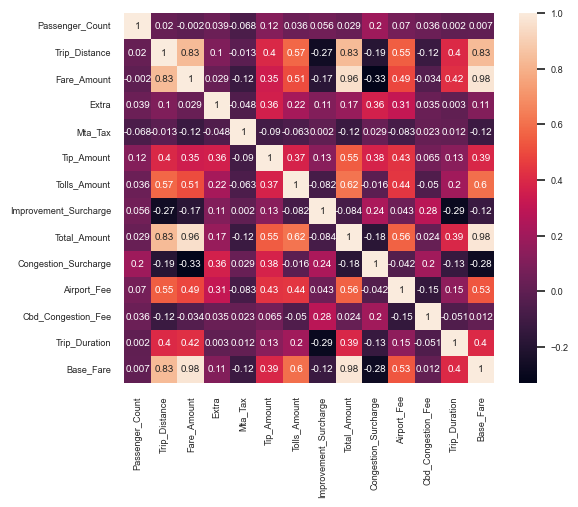

In [63]:
# Now we can map the heatmap of the correlation

cm = np.corrcoef(dfnum.values.T).round(3)

sns.set(font_scale=0.6)
sns.heatmap(cm,
            square=True,
            annot=True,
            yticklabels=dfnum.columns,
            xticklabels=dfnum.columns)
plt.show()

- By looking in the heat map and having as target the **Total_Amount** column, is possible to see the correlation and confirm that Fare_Amount, Trip_Distance, Tips_Amount, Tolls_Amount, Airport_Fee and Trip_Duration have a appropiate correlation value.
- Also Base_Fare looks to have a high correlation but this features is basically the Total_amount with out the tips from the passenger, so maybe i can change to predict this feature, but i think depending the location of the trips the tips have some influence or its more possible to get a tip.              

## Creating dummy values for categorical data
- In this step create dummies for all the categorical features and save it in a new dataframe, i can use this to make some experiments

In [64]:
# Checking the categories for the categorical columns

# Payment type value count
df.Payment_Type.value_counts()

Payment_Type
Credit card    118774
Flex Fare       57562
Cash            15914
Dispute          1614
No charge         631
Name: count, dtype: int64

In [65]:
# Vendor value count

df.Vendor.value_counts()

Vendor
Curb        154259
Creative     37634
Helix         2376
Myle           226
Name: count, dtype: int64

In [66]:
# Rate_Type value count

df.Rate_Type.value_counts()

Rate_Type
Standard rate    188970
JFK                4345
Negotiated          883
Newark              279
Nassau               18
Name: count, dtype: int64

In [67]:
# Stored_Flag value count

df.Stored_Flag.value_counts()

Stored_Flag
N    194379
Y       116
Name: count, dtype: int64

In [68]:
# PU_zone and DO_zone value count 

print(df.DO_zone.value_counts())
df.PU_zone.value_counts()

DO_zone
Yellow Zone    158144
Boro Zone       33780
Airports         2539
EWR                32
Name: count, dtype: int64


PU_zone
Yellow Zone    160601
Boro Zone       22759
Airports        11126
EWR                 9
Name: count, dtype: int64

In [69]:
# creating the dummies for the categorical columns from the dataframe

df_dummys = pd.get_dummies(df, drop_first=True, dtype=int)
df_dummys.reset_index(inplace=True, drop=True)
print(df_dummys.info())
df_dummys.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194495 entries, 0 to 194494
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Passenger_Count           194495 non-null  float64
 1   Trip_Distance             194495 non-null  float64
 2   Fare_Amount               194495 non-null  float64
 3   Extra                     194495 non-null  float64
 4   Mta_Tax                   194495 non-null  float64
 5   Tip_Amount                194495 non-null  float64
 6   Tolls_Amount              194495 non-null  float64
 7   Improvement_Surcharge     194495 non-null  float64
 8   Total_Amount              194495 non-null  float64
 9   Congestion_Surcharge      194495 non-null  float64
 10  Airport_Fee               194495 non-null  float64
 11  Cbd_Congestion_Fee        194495 non-null  float64
 12  Trip_Duration             194495 non-null  float64
 13  Base_Fare                 194495 non-null  f

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,...,Rate_Type_Negotiated,Rate_Type_Newark,Rate_Type_Standard rate,Stored_Flag_Y,PU_zone_Boro Zone,PU_zone_EWR,PU_zone_Yellow Zone,DO_zone_Boro Zone,DO_zone_EWR,DO_zone_Yellow Zone
0,1.0,3.90,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,...,0,0,1,0,0,0,1,0,0,1
1,1.0,13.95,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.0,...,0,0,1,0,1,0,0,1,0,0
2,1.0,13.79,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,...,0,0,1,0,0,0,1,0,0,0
3,1.0,1.76,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,...,0,0,1,0,0,0,1,0,0,1
4,1.0,7.42,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.0,...,0,0,1,0,1,0,0,0,0,1


In [70]:
df_dummys.corr().Total_Amount.abs().sort_values(ascending=False)[1:]

Base_Fare                   0.983947
Fare_Amount                 0.957614
Trip_Distance               0.832628
Tolls_Amount                0.616241
Airport_Fee                 0.563205
Rate_Type_Standard rate     0.555787
Tip_Amount                  0.547253
PU_zone_Yellow Zone         0.427739
Trip_Duration               0.390469
DO_zone_Yellow Zone         0.271676
DO_zone_Boro Zone           0.196534
Congestion_Surcharge        0.182490
Extra                       0.169668
Mta_Tax                     0.122546
Rate_Type_Negotiated        0.105404
Payment_Type_Flex Fare      0.084216
Improvement_Surcharge       0.083936
Rate_Type_Newark            0.081764
PU_zone_Boro Zone           0.081477
DO_zone_EWR                 0.040622
Payment_Type_No charge      0.029897
Passenger_Count             0.028701
Vendor_Curb                 0.028116
Vendor_Helix                0.027464
Payment_Type_Credit card    0.024271
Cbd_Congestion_Fee          0.023822
Payment_Type_Dispute        0.018230
R

# Experiments With feature selection
- In this section i will do some experiments using only the numerical features and other with the dummy dataframe
- Also do fetaure selection by using the high correlated or other feature selection method

# Numerical features Experiment
- these features are the numerical features from the original dataset `dfnum`
- I will create a pipeline for this using all these features and other using SelectFromModel()

### Split the dataset and prepare some lists to store the models

In [71]:
# Selecting target and features
target1 = dfnum.Total_Amount
features1 = dfnum.drop(['Total_Amount','Base_Fare','Fare_Amount'], axis=1) # also drop others fare because those are highly correlated

# splitting the dataset in train and test subssets
X1_train, X1_test, Y1_train, Y1_test = train_test_split(features1, target1, test_size=0.25, random_state = 42)


In [72]:
# Features selected
features1.head()

,Passenger_Count,Trip_Distance,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
0,1.0,3.90,3.25,0.5,2.50,0.00,1.0,2.5,0.0,0.75,10.866667
1,1.0,13.95,0.00,0.5,0.00,7.46,1.0,0.0,0.0,0.00,32.800000
2,1.0,13.79,5.00,0.5,19.57,0.00,1.0,2.5,0.0,0.75,30.383333
3,1.0,1.76,1.00,0.5,0.00,0.00,1.0,2.5,0.0,0.75,10.200000
4,1.0,7.42,0.00,0.5,0.00,0.00,1.0,0.0,0.0,0.75,14.300000


In [73]:
# empty palceholders for model and model names
models = []
names = []

In [74]:
# Models
# Simple Linear Regression

lrmodel = LinearRegression()
models.append(lrmodel)
names.append(lrmodel.__class__.__name__)

# Decision Tree Regression

dtmodel = DecisionTreeRegressor(max_depth=3)
models.append(dtmodel)
names.append(dtmodel.__class__.__name__)

# Random Forest Regression

rfmodel = RandomForestRegressor(max_depth=3, n_estimators=100) 
models.append(rfmodel)
names.append(rfmodel.__class__.__name__)

# Gradient Boosting Regression

gbmodel = GradientBoostingRegressor(max_depth=3,learning_rate=0.1)
models.append(gbmodel)
names.append(gbmodel.__class__.__name__)

# AdaBoost Regression

abmodel = AdaBoostRegressor(n_estimators=100,learning_rate=0.1) 
models.append(abmodel)
names.append(abmodel.__class__.__name__)

# XGBoost Regression

xgmodel = XGBRegressor(n_estimators=100,learning_rate=0.1) 
models.append(xgmodel)
names.append(xgmodel.__class__.__name__)

# CatBoost Regressor

cbmodel = CatBoostRegressor(n_estimators=100,learning_rate=0.1, verbose=False)
models.append(cbmodel)
names.append(cbmodel.__class__.__name__)

# LightGBM Regressor

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, verbosity=-1) 
models.append(lgbm_model)
names.append(lgbm_model.__class__.__name__)

# SGD Regressor

sgd_model = SGDRegressor(max_iter=1000, tol=1e-4,eta0=0.01, random_state=42) 
models.append(sgd_model)
names.append(sgd_model.__class__.__name__)


### Pipeline with all the features

In [75]:
# empty palceholder to save the results of the experiment

r2_1 = []
rmse1 = []

In [76]:
# Pipeline using the models and all the features
for model in models:
    pipe1 = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", model) 
    ])
    pipe1.fit(X1_train, Y1_train)
    Y1_pred = pipe1.predict(X1_test)
    r2_1.append(pipe1.score(X1_test, Y1_test) )
    rmse1.append(root_mean_squared_error(Y1_test, Y1_pred))

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [77]:
# plotting the results 

result_df1 = pd.DataFrame(zip(names,r2_1, rmse1), columns=['Regressor', 'R^2 Score', 'RMSE Score'])
result_df1.sort_values(by=['R^2 Score', 'RMSE Score'], ascending=[False,True])

,Regressor,R^2 Score,RMSE Score
7,LGBMRegressor,0.912543,5.273371
5,XGBRegressor,0.912306,5.280499
6,CatBoostRegressor,0.908655,5.389319
3,GradientBoostingRegressor,0.904785,5.502293
0,LinearRegression,0.827787,7.399859
8,SGDRegressor,0.826256,7.432670
2,RandomForestRegressor,0.798133,8.011681
1,DecisionTreeRegressor,0.790636,8.159076
4,AdaBoostRegressor,0.718105,9.467467


- By using all the features the best pipe is LGBMRegressor.
- The majority boosting models shows a very good R2 score.
- Models like LinearRegression and SGDRegresso perform slightly worse but still doing a good performance.

### Pipeline using SelectFromModel()

In [78]:
# empty placeholders
r2_2 = []
rmse2 = []

In [79]:
# SelectFromModel feature selection with RandomForestRegressor

selector = SelectFromModel(RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),threshold=0.01)

In [80]:
# Pipeline using the models and all the features
for model in models:
    pipe2 = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", selector),
        ("regressor", model) 
    ])
    pipe2.fit(X1_train, Y1_train)
    Y1_pred = pipe2.predict(X1_test)
    r2_2.append(pipe2.score(X1_test, Y1_test) )
    rmse2.append(root_mean_squared_error(Y1_test, Y1_pred))

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [81]:
# Check selected features
selected = X1_train.columns[pipe2.named_steps["selector"].get_support()]
print("Selected features:", list(selected))

Selected features: ['Trip_Distance', 'Tip_Amount', 'Trip_Duration']


In [82]:
# plotting the results 

result_df2 = pd.DataFrame(zip(names,r2_2, rmse2), columns=['Regressor', 'R^2 Score', 'RMSE Score'])
result_df2.sort_values(by=['R^2 Score', 'RMSE Score'], ascending=[False,True])

,Regressor,R^2 Score,RMSE Score
7,LGBMRegressor,0.871875,6.382751
5,XGBRegressor,0.871025,6.403875
6,CatBoostRegressor,0.868407,6.468543
3,GradientBoostingRegressor,0.867661,6.486848
2,RandomForestRegressor,0.797399,8.026230
1,DecisionTreeRegressor,0.790636,8.159076
0,LinearRegression,0.757226,8.786002
8,SGDRegressor,0.756254,8.803581
4,AdaBoostRegressor,0.729227,9.278826


- The performance order results are similar to the first experiment.
- Using all numerical features gives slightly better results than SelectFromModel, but the difference is small because only a few features ['Trip_Distance', 'Tip_Amount', 'Trip_Duration'] dominate the prediction.
- But i consider that this results is more realistic because dont use all the features, instead only use some important features.

# Dummy features Experiment
- In this experiment i am using the dataframe includeing the categorical features converted into Dummies from the original dataset `df_dummys`
- I will create a pipeline for this using all these features and other using SelectFromModel()

### Splitting the data

In [83]:
# Selecting target and features
target2 = df_dummys.Total_Amount
features2 = df_dummys.drop(['Total_Amount','Base_Fare','Fare_Amount'], axis=1) # also drop others fare because those are highly correlated

# splitting the dataset in train and test subssets
X2_train, X2_test, Y2_train, Y2_test = train_test_split(features2, target2, test_size=0.25, random_state = 42)

In [84]:
# Features selected
features2.head()

,Passenger_Count,Trip_Distance,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,...,Rate_Type_Negotiated,Rate_Type_Newark,Rate_Type_Standard rate,Stored_Flag_Y,PU_zone_Boro Zone,PU_zone_EWR,PU_zone_Yellow Zone,DO_zone_Boro Zone,DO_zone_EWR,DO_zone_Yellow Zone
0,1.0,3.90,3.25,0.5,2.50,0.00,1.0,2.5,0.0,0.75,...,0,0,1,0,0,0,1,0,0,1
1,1.0,13.95,0.00,0.5,0.00,7.46,1.0,0.0,0.0,0.00,...,0,0,1,0,1,0,0,1,0,0
2,1.0,13.79,5.00,0.5,19.57,0.00,1.0,2.5,0.0,0.75,...,0,0,1,0,0,0,1,0,0,0
3,1.0,1.76,1.00,0.5,0.00,0.00,1.0,2.5,0.0,0.75,...,0,0,1,0,0,0,1,0,0,1
4,1.0,7.42,0.00,0.5,0.00,0.00,1.0,0.0,0.0,0.75,...,0,0,1,0,1,0,0,0,0,1


### Pipeline using all the features

In [85]:
# empty palceholder to save the results of the experiment

r2_3 = []
rmse3 = []

In [86]:
# Pipeline using the models and all the features
for model in models:
    pipe3 = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", model) 
    ])
    pipe3.fit(X2_train, Y2_train)
    Y2_pred = pipe3.predict(X2_test)
    r2_3.append(pipe3.score(X2_test, Y2_test) )
    rmse3.append(root_mean_squared_error(Y2_test, Y2_pred))

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [87]:
# plotting the results 

result_df3 = pd.DataFrame(zip(names,r2_3, rmse3), columns=['Regressor', 'R^2 Score', 'RMSE Score'])
result_df3.sort_values(by=['R^2 Score', 'RMSE Score'], ascending=[False,True])

,Regressor,R^2 Score,RMSE Score
5,XGBRegressor,9.230610e-01,4.946109e+00
7,LGBMRegressor,9.229495e-01,4.949693e+00
6,CatBoostRegressor,9.201493e-01,5.038832e+00
3,GradientBoostingRegressor,9.148700e-01,5.202736e+00
0,LinearRegression,8.414558e-01,7.100119e+00
2,RandomForestRegressor,8.057247e-01,7.859579e+00
1,DecisionTreeRegressor,7.907114e-01,8.157617e+00
4,AdaBoostRegressor,7.461809e-01,8.983645e+00
8,SGDRegressor,-1.490227e+18,2.176791e+10


### Pipeline using SelectFromModel

In [88]:
# empty placeholders
r2_4 = []
rmse4 = []

In [89]:
# Pipeline using the models and all the features
for model in models:
    pipe4 = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", selector),
        ("regressor", model) 
    ])
    pipe4.fit(X2_train, Y2_train)
    Y2_pred = pipe4.predict(X2_test)
    r2_4.append(pipe4.score(X2_test, Y2_test) )
    rmse4.append(root_mean_squared_error(Y2_test, Y2_pred))

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [90]:
# Check selected features
selected2 = X2_train.columns[pipe4.named_steps["selector"].get_support()]
print("Selected features:", list(selected2))

Selected features: ['Trip_Distance', 'Tip_Amount', 'Trip_Duration', 'Rate_Type_Standard rate']


In [91]:
# plotting the results 

result_df4 = pd.DataFrame(zip(names,r2_4, rmse4), columns=['Regressor', 'R^2 Score', 'RMSE Score'])
result_df4.sort_values(by=['R^2 Score', 'RMSE Score'], ascending=[False,True])

,Regressor,R^2 Score,RMSE Score
7,LGBMRegressor,0.884398,6.062796
5,XGBRegressor,0.884106,6.070438
6,CatBoostRegressor,0.882627,6.109050
3,GradientBoostingRegressor,0.880079,6.175017
2,RandomForestRegressor,0.804258,7.889181
1,DecisionTreeRegressor,0.790711,8.157617
0,LinearRegression,0.766915,8.608892
8,SGDRegressor,0.765814,8.629216
4,AdaBoostRegressor,0.764717,8.649392


- Adding categorical features as one-hot encoded dummies significantly improves the model performance.
- The R2 increases from 0.871 to 0.884 and RMSE decreases from 6.38 to 6.382.
- This shows that pickup and drop-off zones, rate type, or vendor maybe has meaningful predictive information about the total fare.

# Selecting Best Pipe 
- Although the models trained using all numerical features achieved slightly higher R2 scores and lower RMSE, i consider that these results are maybe inflated because some features are strongly correlated with the target and could introduce leakage.
- By using SelectFromModel feature selection, we remove redundant or overly influential features.
- when including categorical features as dummies, the model captures additional patterns improving the performance.
- Therefore, despite the slightly lower perfomance compared to the experiments with all the features, i consider the SelectFromModel with dummies models to be the most realistic and robust choice for predicting trip fares in this dataset.
- From the experiment for SelectFromModel with dummies, the best pipe was **LGBMRegressor** with a R2 = 0.884398 and RMSE = 6.062796.

In [92]:
# Based in the previus Score table the CatBoostRegressor model is the best because higher R2 score and a low RMSE score

best_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, verbosity=-1) 
bestPipe = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", selector),
    ("regressor", best_model)
])

bestPipe.fit(X2_train, Y2_train)


,steps,"[('scaler', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,RandomForestR...ndom_state=42)
,threshold,0.01
,prefit,False
,norm_order,1


In [93]:
# prediction using the model LGBM Regressor
Y_best_pred = bestPipe.predict(X2_test)

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


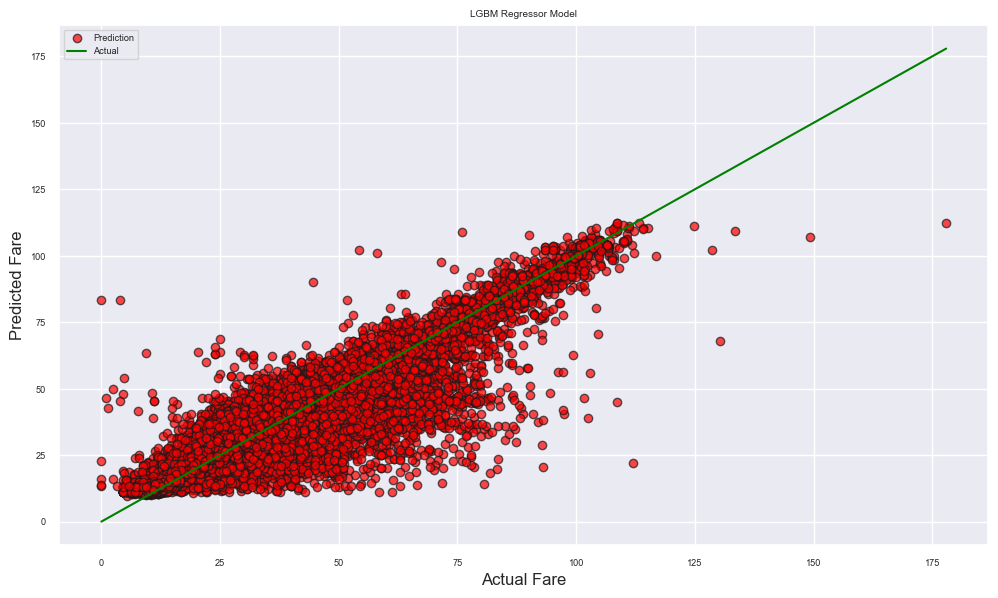

In [94]:
# plot Actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(Y2_test, Y_best_pred, alpha=0.7, color='red', edgecolors='k', label='Prediction')
plt.plot([Y2_test.min(), Y2_test.max()], [Y2_test.min(), Y2_test.max()], color='green', label='Actual')

plt.xlabel('Actual Fare', fontsize=12)
plt.ylabel('Predicted Fare', fontsize=12)
plt.title('LGBM Regressor Model')
plt.legend()
plt.tight_layout()
plt.show()

# Out-of-sample Predictions Using New Data
- The final prediction was performed using the best model on a new dataset from the same source as the training data, but collected in a different month of the same year (February-2026). This ensures the evaluation is done on unseen data while maintaining consistency in data origin.
- The new dataset has the same format and structure as the training dataset, and therefore the same preprocessing and cleaning procedures were applied to maintain consistency for model prediction. Additional information can be found in the **New_Dataset_test.ipynb** file.

## Reading the new data set and having a peek on the content

In [95]:
# Reading the df_dummys_test.csv file that contains the total new data
df_dummys_test = pd.read_csv('Dataset/df_dummys_test.csv')
df_dummys_test.head()

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,...,Rate_Type_Negotiated,Rate_Type_Newark,Rate_Type_Standard rate,Stored_Flag_Y,PU_zone_Boro Zone,PU_zone_EWR,PU_zone_Yellow Zone,DO_zone_Boro Zone,DO_zone_EWR,DO_zone_Yellow Zone
0,1.0,17.47,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,...,0,0,1,0,0,0,1,0,0,0
1,1.0,2.14,16.96,0.0,0.5,0.00,0.00,1.0,22.96,0.0,...,0,0,1,0,0,0,1,0,0,1
2,1.0,1.27,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,...,0,0,1,0,0,0,1,0,0,1
3,2.0,1.41,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,...,0,0,1,0,0,0,1,0,0,1
4,2.0,2.73,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,...,0,0,1,0,0,0,1,0,0,1


In [96]:
# Info of the dataframe df_dummys_test 
df_dummys_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195133 entries, 0 to 195132
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Passenger_Count           195133 non-null  float64
 1   Trip_Distance             195133 non-null  float64
 2   Fare_Amount               195133 non-null  float64
 3   Extra                     195133 non-null  float64
 4   Mta_Tax                   195133 non-null  float64
 5   Tip_Amount                195133 non-null  float64
 6   Tolls_Amount              195133 non-null  float64
 7   Improvement_Surcharge     195133 non-null  float64
 8   Total_Amount              195133 non-null  float64
 9   Congestion_Surcharge      195133 non-null  float64
 10  Airport_Fee               195133 non-null  float64
 11  Cbd_Congestion_Fee        195133 non-null  float64
 12  Trip_Duration             195133 non-null  float64
 13  Base_Fare                 195133 non-null  f

## Splitting the data 

In [97]:
# Selecting target and features
target_test = df_dummys_test.Total_Amount
features_test = df_dummys_test.drop(['Total_Amount','Base_Fare','Fare_Amount'], axis=1) # also drop others fare because those are highly correlated

# splitting the dataset in train and test subssets
Xt_train, Xt_test, Yt_train, Yt_test = train_test_split(features_test, target_test, test_size=0.25, random_state = 42)


## Prediction with the best model and New Data

In [98]:
# prediction using the model LGBM Regressor
Y_best_pred_test = bestPipe.predict(Xt_test)

C:\Users\Isaac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


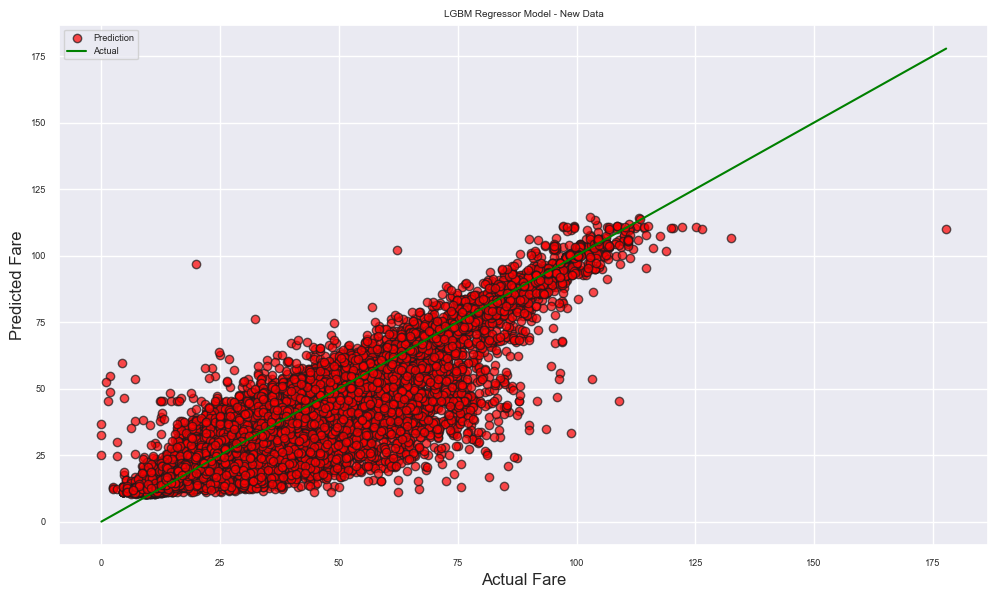

In [99]:
# plot Actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(Yt_test, Y_best_pred_test, alpha=0.7, color='red', edgecolors='k', label='Prediction')
plt.plot([Yt_test.min(), Yt_test.max()], [Yt_test.min(), Yt_test.max()], color='green', label='Actual')

plt.xlabel('Actual Fare', fontsize=12)
plt.ylabel('Predicted Fare', fontsize=12)
plt.title('LGBM Regressor Model - New Data')
plt.legend()
plt.tight_layout()
plt.show()

- The model is generally accurate and captures the overall relationship between actual and predicted fares.
- There is some dispersion around the diagonal line, indicating moderate prediction error.
- As fare values increase, the spread of predictions also increases, showing higher variability.
- For higher fares, predictions tend to slightly underestimate, with many points falling below the line.
- A few outliers are present, where predictions deviate significantly from actual values.
- Similar patterns were observed when evaluating the model on both the training dataset and a completely new dataset, suggesting consistent performance and good generalization.